# Cross-Dataset Transfer & Window-Shape Agreement — SDC-2023 → Warwick SE-NAV

`warwick_multipath/sdc_to_warwick_transfer.ipynb` established a **feature-level**
transfer result: a Random Forest trained only on real smartphone data ranks NLOS
on an independent ray-traced simulation of the Warwick campus at ROC-AUC ≈ 0.94,
which argues the detector learned transferable physics (low C/N0 at low elevation)
rather than device quirks.

This notebook adds the **temporal** counterpart, in two parts:

1. **Sequence transfer.** Apply the SDC-trained attention BRNN from notebook 02 to
   Warwick-windowed sequences on the shared feature schema, and report ROC-AUC
   directly against that RF baseline.
2. **Independent window discovery — the new result.** Run the whole
   attention/occlusion window-discovery analysis on Warwick's *own* sequences,
   training from scratch on Warwick alone, and compare the discovered window shape
   with SDC-2023's.

The logic of part 2 is worth stating plainly, because it is the point of the
notebook. The two datasets share almost nothing: one is a real Android receiver
driving around California with a hardware `MultipathIndicator` flag, the other is
a noise-free SE-NAV ray-tracing simulation of a Coventry campus with geometric
NLOS ground truth. They share no hardware, no location, no label definition and no
noise model. If a model trained separately on each nevertheless finds that the
*same* number of neighbouring epochs carries the signal, that shape is very hard
to explain as a quirk of either dataset — the natural explanation is the physical
process both are sampling: a vehicle moving past a reflector for some
characteristic number of seconds.

A negative result is equally publishable and must not be talked around: if the
shapes disagree, the honest conclusion is that the discovered "memory" is
dataset-specific, and §5 reports the disagreement as measured.

## 0. Setup

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sys.path.insert(0, os.getcwd())
import attn_brnn as ab
from attn_brnn import (AttnBRNN, WindowBatcher, valid_centers, set_seed, rmpe, n_params,
                       train_model, predict_proba, collect_labels, attention_profile,
                       attention_span, occlusion_profile, tune_threshold, evaluate)

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '../..'))
SDC_CACHE = os.path.join(BASE_DIR, 'data/03_processed/seq_sdc2023.npz')
WAR_CACHE = os.path.join(BASE_DIR, 'data/03_processed/seq_warwick.npz')
ART_DIR   = os.path.join(BASE_DIR, 'data/03_processed/attn_brnn')
CKPT      = os.path.join(ART_DIR, 'sdc_attn_brnn.pt')

SEED = 42
set_seed(SEED)
DEVICE = ab.get_device()

print('device:', DEVICE)
for p in (SDC_CACHE, WAR_CACHE, CKPT):
    print(f'  {os.path.basename(p):28} exists: {os.path.exists(p)}')
assert os.path.exists(CKPT), 'Run 02_sdc_attention_brnn.ipynb first — it writes the checkpoint.'

device: cpu
  seq_sdc2023.npz              exists: True
  seq_warwick.npz              exists: True
  sdc_attn_brnn.pt             exists: True


## 1. Load the Warwick sequences and the SDC-trained model

The **shared schema** is the four channels both datasets provide, in an identical
order fixed by notebook 01: `Cn0DbHz` (`snr_dbHz` in the simulation — the same
dB-Hz carrier-to-noise quantity), `elev_deg`, `az_sin`, `az_cos`. This mirrors the
`engineer()` function of `sdc_to_warwick_transfer.ipynb`, minus its categorical
one-hot buckets, which a network does not need.

In [2]:
zs = np.load(SDC_CACHE, allow_pickle=False)
zw = np.load(WAR_CACHE, allow_pickle=False)

ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
HYPER = ck['hyper']
K_MAX, K_ATTN, K_OCC = HYPER['k_max'], HYPER['k_attn'], HYPER['k_occ']
SHARED_COLS = ck['scaler_shared']['cols']

sdc_shared_cols = [str(s) for s in zs['shared_features']]
war_shared_cols = [str(s) for s in zw['shared_features']]
assert sdc_shared_cols == war_shared_cols == SHARED_COLS, 'shared channel order mismatch'

F_war_shared = zw['F_shared']
F_war_own    = zw['F_own']
y_war        = zw['y'].astype(np.float32)
seg_war      = zw['seg']
split_war    = zw['split']
WAR_OWN_COLS = [str(s) for s in zw['own_features']]

print(f'Warwick rows: {len(y_war):,}  |  NLOS rate {100*y_war.mean():.1f}%')
print(f'shared channels: {SHARED_COLS}')
print(f'warwick own channels: {WAR_OWN_COLS}')
print(f'\nFrom notebook 02 — k_max={K_MAX}, attention k={K_ATTN}, occlusion k={K_OCC}')
print('SDC shared-schema thresholds:', {k: round(v, 3) for k, v in ck['thresholds'].items()})

Warwick rows: 24,849  |  NLOS rate 20.0%
shared channels: ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos']
warwick own channels: ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos', 'power_dbW']

From notebook 02 — k_max=20, attention k=16, occlusion k=15
SDC shared-schema thresholds: {'BiLSTM-unpacked|k=15': 0.44, 'BiLSTM-packed|k=15': 0.44, 'BiLSTM-unpacked|k=16': 0.61, 'BiLSTM-packed|k=16': 0.61, 'BiLSTM-unpacked|k=20': 0.66, 'BiLSTM-packed|k=20': 0.66}


### 1a. The domain shift, restated

`sdc_to_warwick_transfer.ipynb` found the simulation's C/N0 sits ~12 dB above the
real device's, and concluded that the model's *ranking* transfers while its
*threshold* does not. That finding governs this notebook too, and it dictates a
specific decision below: **the Warwick features are standardised with Warwick's
own training statistics, not SDC's.**

This deserves justification, because it is not the leak-free convention used
elsewhere. Applying SDC's scaler to Warwick would map every simulated C/N0 to
roughly +2 standard deviations, pushing the entire test set into a region of input
space the network never saw in training — that measures the 12 dB offset, not
whether the temporal pattern transfers. Re-standardising per domain is the
distribution-level equivalent of the threshold recalibration the RF notebook
already performs, and it is *not* fitting to the labels: only the input mean and
variance are used, never `y`. Both variants are reported in §2 so the cost of the
choice is visible rather than assumed.

In [3]:
war_train = split_war == 0
mu_w = F_war_shared[war_train].mean(0)
sd_w = F_war_shared[war_train].std(0); sd_w[sd_w < 1e-8] = 1.0

mu_s = ck['scaler_shared']['mu']
sd_s = ck['scaler_shared']['sd']

F_war_selfscaled = (F_war_shared - mu_w) / sd_w      # Warwick's own statistics
F_war_sdcscaled  = (F_war_shared - mu_s) / sd_s      # SDC's statistics, unchanged

print(f'{"channel":10} {"SDC mean":>10} {"SDC sd":>9} {"War mean":>10} {"War sd":>9} '
      f'{"War in SDC z-units":>20}')
for i, c in enumerate(SHARED_COLS):
    z_in_sdc = (F_war_shared[:, i].mean() - mu_s[i]) / sd_s[i]
    print(f'{c:10} {mu_s[i]:>10.3f} {sd_s[i]:>9.3f} {mu_w[i]:>10.3f} {sd_w[i]:>9.3f} '
          f'{z_in_sdc:>20.2f}')

channel      SDC mean    SDC sd   War mean    War sd   War in SDC z-units
Cn0DbHz        32.252     6.025     39.812    11.888                 1.27
elev_deg       39.003    21.307     28.886    18.731                -0.45
az_sin         -0.060     0.767     -0.239     0.692                -0.22
az_cos          0.076     0.634      0.036     0.681                -0.07


## 2. Sequence transfer — SDC-trained model applied to Warwick

No retraining and no fine-tuning: the network trained on Californian smartphone
drives is handed 41-epoch windows of simulated Coventry satellite tracks. As in
the RF notebook, **ROC-AUC is the headline** because it is threshold-free, and the
threshold is separately recalibrated on the target to give a usable operating
point.

In [4]:
def build_shared(variant, k):
    m = AttnBRNN(len(SHARED_COLS), hidden=HYPER['hidden'], layers=HYPER['layers'],
                 rnn='lstm' if 'LSTM' in variant else 'gru',
                 attn='packed' if 'packed' in variant else 'unpacked',
                 dropout=HYPER['dropout']).to(DEVICE)
    m.load_state_dict(ck['shared_state'][f'{variant}|k={k}'])
    m.eval()
    return m

def war_batchers(F, k, batch=512, shuffle_train=False):
    Fd = torch.from_numpy(F.astype(np.float32)).to(DEVICE)
    yd = torch.from_numpy(y_war).to(DEVICE)
    c = valid_centers(seg_war, k)
    out = {'all': WindowBatcher(Fd, yd, c, k, batch_size=batch)}
    for name, code in [('train', 0), ('val', 1), ('test', 2)]:
        out[name] = WindowBatcher(Fd, yd, c[split_war[c] == code], k, batch_size=batch,
                                  shuffle=(shuffle_train and name == 'train'))
    return out

transfer_rows = []
available = sorted({tuple(kk.split('|k=')) for kk in ck['shared_state']})
for variant, kstr in available:
    k = int(kstr)
    m = build_shared(variant, k)
    for scaling, F in [('warwick-own stats', F_war_selfscaled), ('sdc stats', F_war_sdcscaled)]:
        b = war_batchers(F, k)['all']
        yy = collect_labels(b)
        pp = predict_proba(m, b)
        thr = tune_threshold(yy, pp)                 # recalibrated on target, as in the RF notebook
        r = evaluate(yy, pp, thr)
        r.update(model=variant, k=k, scaling=scaling, windows=len(yy),
                 f1_at_sdc_thr=evaluate(yy, pp, ck['thresholds'][f'{variant}|k={k}'])['f1'])
        transfer_rows.append(r)

transfer = pd.DataFrame(transfer_rows)[
    ['model', 'k', 'scaling', 'windows', 'roc_auc', 'pr_auc', 'f1', 'precision', 'recall',
     'threshold', 'f1_at_sdc_thr']]
print('SDC-trained sequence model -> Warwick simulation (no retraining):')
print(transfer.sort_values('roc_auc', ascending=False).round(4).to_string(index=False))

SDC-trained sequence model -> Warwick simulation (no retraining):
          model  k           scaling  windows  roc_auc  pr_auc     f1  precision  recall  threshold  f1_at_sdc_thr
  BiLSTM-packed 16         sdc stats    20674   0.9911  0.9384 0.8866     0.8816  0.8915       0.56         0.8817
BiLSTM-unpacked 16         sdc stats    20674   0.9911  0.9384 0.8866     0.8816  0.8915       0.56         0.8817
  BiLSTM-packed 15         sdc stats    20846   0.9905  0.9271 0.8985     0.8298  0.9796       0.29         0.8789
BiLSTM-unpacked 15         sdc stats    20846   0.9905  0.9271 0.8985     0.8298  0.9796       0.29         0.8789
  BiLSTM-packed 20         sdc stats    20023   0.9879  0.8955 0.8578     0.8139  0.9067       0.38         0.7921
BiLSTM-unpacked 20         sdc stats    20023   0.9879  0.8955 0.8578     0.8139  0.9067       0.38         0.7921
  BiLSTM-packed 16 warwick-own stats    20674   0.5831  0.1809 0.3202     0.2019  0.7738       0.62         0.3195
BiLSTM-unpacke

### 2a. Against the Random Forest transfer baseline

The RF baseline is re-run here rather than quoted, so both models are measured on
**exactly the same Warwick rows** — the sequence model can only score the 80.6% of
rows that sit at the centre of a complete window, and comparing against a number
computed over all 24,849 rows would be comparing different test sets.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc as sk_auc

F_sdc_shared = zs['F_shared']
y_sdc = zs['y'].astype(int)
split_sdc = zs['split']
seg_sdc = zs['seg']

sdc_tr = split_sdc == 0
rf = ImbPipeline([('smote', SMOTE(random_state=SEED)),
                  ('rf', RandomForestClassifier(n_estimators=300, max_depth=16,
                                                min_samples_leaf=2, random_state=SEED,
                                                n_jobs=-1))])
idx = np.flatnonzero(sdc_tr)
sub = np.random.default_rng(SEED).choice(idx, size=min(250_000, len(idx)), replace=False)
t0 = time.time()
rf.fit(F_sdc_shared[sub], y_sdc[sub])
print(f'RF trained on {len(sub):,} SDC rows (shared schema, raw units) in {time.time()-t0:.0f}s')

best_k_transfer = int(transfer.sort_values('roc_auc', ascending=False).iloc[0]['k'])
centres_w = valid_centers(seg_war, best_k_transfer)
rf_prob = rf.predict_proba(F_war_shared[centres_w])[:, 1]
rf_y = y_war[centres_w]
rf_thr = tune_threshold(rf_y, rf_prob)
rf_res = evaluate(rf_y, rf_prob, rf_thr); rf_res['model'] = 'Random Forest (shared feats)'

seq_best = transfer.sort_values('roc_auc', ascending=False).iloc[0]
print(f'\nOn the identical {len(centres_w):,} Warwick windows (k={best_k_transfer}):')
print(f'  Random Forest        ROC-AUC {rf_res["roc_auc"]:.4f}   F1 {rf_res["f1"]:.4f}  '
      f'(recalibrated thr {rf_thr:.2f})')
print(f'  {seq_best.model} k={int(seq_best.k)}  ROC-AUC {seq_best.roc_auc:.4f}   '
      f'F1 {seq_best.f1:.4f}  (recalibrated thr {seq_best.threshold:.2f})')

RF trained on 250,000 SDC rows (shared schema, raw units) in 93s

On the identical 20,674 Warwick windows (k=16):
  Random Forest        ROC-AUC 0.8736   F1 0.6805  (recalibrated thr 0.33)
  BiLSTM-packed k=16  ROC-AUC 0.9911   F1 0.8866  (recalibrated thr 0.56)


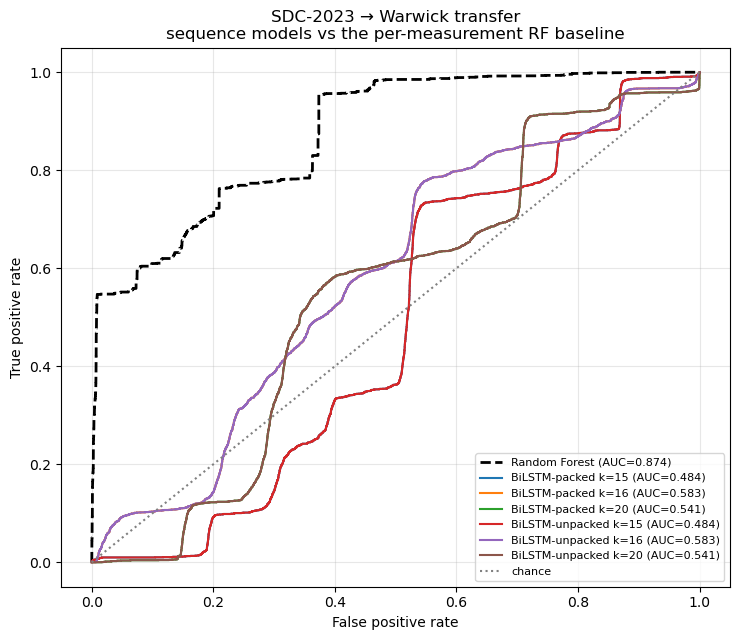

In [6]:
plt.figure(figsize=(7.5, 6.5))
fpr, tpr, _ = roc_curve(rf_y, rf_prob)
plt.plot(fpr, tpr, 'k--', lw=2, label=f'Random Forest (AUC={sk_auc(fpr,tpr):.3f})')
for _, r in transfer[transfer.scaling == 'warwick-own stats'].iterrows():
    m = build_shared(r.model, int(r.k))
    b = war_batchers(F_war_selfscaled, int(r.k))['all']
    f2, t2, _ = roc_curve(collect_labels(b), predict_proba(m, b))
    plt.plot(f2, t2, label=f'{r.model} k={int(r.k)} (AUC={sk_auc(f2,t2):.3f})')
plt.plot([0, 1], [0, 1], ':', color='gray', label='chance')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('SDC-2023 → Warwick transfer\nsequence models vs the per-measurement RF baseline')
plt.legend(loc='lower right', fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Warwick's own sequence model — trained from scratch on the simulation

Part 2 asked whether an SDC-trained model works on Warwick. Part 3 asks a
different and more interesting question: **what window does Warwick discover on
its own?** The model here never sees SDC data. It is trained on Warwick's training
epochs with the same architecture, the same hyperparameters and the same
procedure as notebook 02, so any difference in the discovered window comes from
the data rather than from the setup.

Two caveats to keep in view when reading the numbers:

- Warwick is **small** — 14,018 training windows against SDC's 273,615 — so its
  attention profile is noisier and its scores less stable.
- Warwick is **noise-free**, and its labels are correspondingly far more
  persistent (notebook 01: P(NLOS | NLOS 1 epoch ago) = 0.98, against 0.49 for
  SDC). The task is genuinely easier here, so absolute scores are not comparable
  across the two datasets. Only the **shape** of the window is.

In [7]:
EPOCHS, PATIENCE, LR, BATCH = 25, 5, 1e-3, 256

war_tr_centres = valid_centers(seg_war, K_MAX)
war_tr_centres = war_tr_centres[split_war[war_tr_centres] == 0]
pw_war = float((1 - y_war[war_tr_centres].mean()) / y_war[war_tr_centres].mean())
print(f'Warwick pos_weight: {pw_war:.2f}  |  training windows at k={K_MAX}: '
      f'{len(war_tr_centres):,}')

war_trained, war_rows = {}, []
for variant in ['BiLSTM-packed', 'BiLSTM-unpacked', 'BiGRU-packed', 'BiGRU-unpacked']:
    set_seed(SEED)
    m = AttnBRNN(len(SHARED_COLS), hidden=HYPER['hidden'], layers=HYPER['layers'],
                 rnn='lstm' if 'LSTM' in variant else 'gru',
                 attn='packed' if 'packed' in variant else 'unpacked',
                 dropout=HYPER['dropout']).to(DEVICE)
    b = war_batchers(F_war_selfscaled, K_MAX, batch=BATCH, shuffle_train=True)
    m, _, bv = train_model(m, b['train'], b['val'], pos_weight=pw_war, epochs=EPOCHS,
                           lr=LR, patience=PATIENCE, verbose=False)
    thr = tune_threshold(collect_labels(b['val']), predict_proba(m, b['val']))
    r = evaluate(collect_labels(b['test']), predict_proba(m, b['test']), thr)
    r.update(model=variant, k=K_MAX, val_auc=bv)
    war_trained[variant] = m
    war_rows.append(r)
    print(f'  {variant:17} val ROC-AUC {bv:.4f}  |  test ROC-AUC {r["roc_auc"]:.4f}  '
          f'F1 {r["f1"]:.4f}')

war_df = pd.DataFrame(war_rows)[['model', 'roc_auc', 'pr_auc', 'f1', 'precision', 'recall']]
print('\nWarwick-trained, Warwick-tested (temporal split, last 30% of the drive):')
print(war_df.round(4).to_string(index=False))

Warwick pos_weight: 4.65  |  training windows at k=20: 14,018
  BiLSTM-packed     val ROC-AUC 0.9996  |  test ROC-AUC 0.9996  F1 0.9774
  BiLSTM-unpacked   val ROC-AUC 0.9996  |  test ROC-AUC 0.9996  F1 0.9774
  BiGRU-packed      val ROC-AUC 0.9989  |  test ROC-AUC 0.9995  F1 0.9882
  BiGRU-unpacked    val ROC-AUC 0.9989  |  test ROC-AUC 0.9995  F1 0.9882

Warwick-trained, Warwick-tested (temporal split, last 30% of the drive):
          model  roc_auc  pr_auc     f1  precision  recall
  BiLSTM-packed   0.9996  0.9943 0.9774     0.9878  0.9673
BiLSTM-unpacked   0.9996  0.9943 0.9774     0.9878  0.9673
   BiGRU-packed   0.9995  0.9917 0.9882     0.9795  0.9970
 BiGRU-unpacked   0.9995  0.9917 0.9882     0.9795  0.9970


## 4. Window discovery on Warwick

The same two measurements as notebook 02 §6: the attention profile over the window,
and the occlusion profile that checks whether the *input* at each offset actually
moves the output.

BiLSTM-packed: attention (1, 41), occlusion (41,)
BiLSTM-unpacked: attention (1, 41), occlusion (41,)
BiGRU-packed: attention (1, 41), occlusion (41,)
BiGRU-unpacked: attention (1, 41), occlusion (41,)


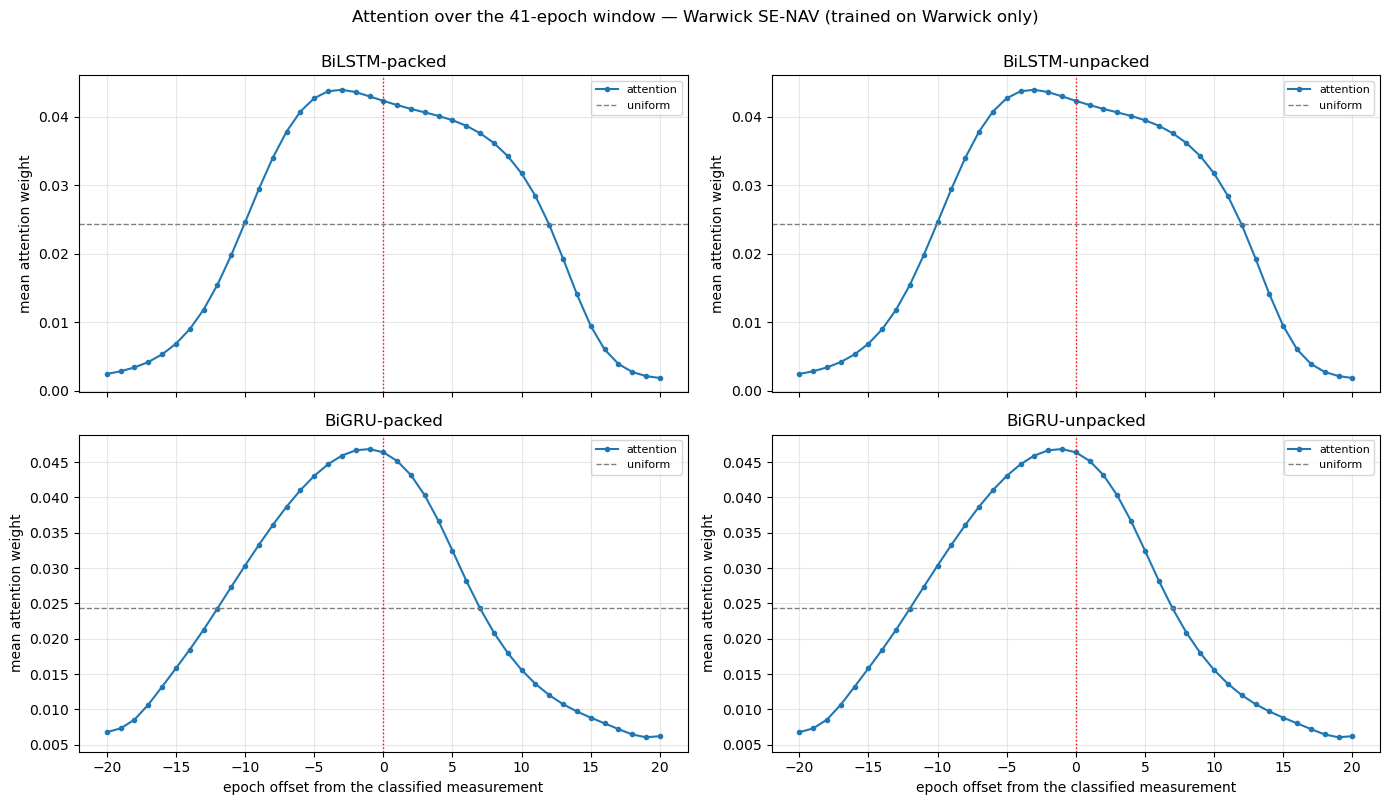

Warwick discovered window (90% of mass):
   source           model head  k_symmetric  k_past  k_future  centre_weight
attention   BiLSTM-packed both           13      12        13         0.0423
attention BiLSTM-unpacked both           13      12        13         0.0423
attention    BiGRU-packed both           15      15        15         0.0464
attention  BiGRU-unpacked both           15      15        15         0.0464
occlusion   BiLSTM-packed both           15      17        13         0.0516
occlusion BiLSTM-unpacked both           15      17        13         0.0516
occlusion    BiGRU-packed both           15      13        17         0.0408
occlusion  BiGRU-unpacked both           15      13        17         0.0408

--> Warwick: attention k = 14, occlusion k = 15


In [8]:
b_war = war_batchers(F_war_selfscaled, K_MAX, batch=BATCH)
offsets = np.arange(-K_MAX, K_MAX + 1)
uniform = 1.0 / (2 * K_MAX + 1)

war_profiles, war_occ = {}, {}
for variant, m in war_trained.items():
    prof, _ = attention_profile(m, b_war['val'])
    war_profiles[variant] = prof
    war_occ[variant] = occlusion_profile(m, b_war['val'], K_MAX)
    print(f'{variant}: attention {prof.shape}, occlusion {war_occ[variant].shape}')

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (variant, prof) in zip(axes.ravel(), war_profiles.items()):
    labels = ['attention'] if prof.shape[0] == 1 else ['forward direction', 'backward direction']
    for h in range(prof.shape[0]):
        ax.plot(offsets, prof[h], marker='o', ms=3, label=labels[h])
    ax.axhline(uniform, ls='--', color='gray', lw=1, label='uniform')
    ax.axvline(0, color='red', ls=':', lw=1)
    ax.set_title(variant); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax.set_ylabel('mean attention weight')
for ax in axes[1]:
    ax.set_xlabel('epoch offset from the classified measurement')
plt.suptitle('Attention over the 41-epoch window — Warwick SE-NAV (trained on Warwick only)', y=1.0)
plt.tight_layout(); plt.show()

war_span = []
for variant, prof in war_profiles.items():
    for h in range(prof.shape[0]):
        s = attention_span(prof[h], mass=0.90)
        s.update(model=variant, head='both' if prof.shape[0] == 1 else
                 ('forward' if h == 0 else 'backward'), source='attention')
        war_span.append(s)
for variant, o in war_occ.items():
    s = attention_span(o, mass=0.90)
    s.update(model=variant, head='both', source='occlusion')
    war_span.append(s)

war_span_df = pd.DataFrame(war_span)[
    ['source', 'model', 'head', 'k_symmetric', 'k_past', 'k_future', 'centre_weight']]
print('Warwick discovered window (90% of mass):')
print(war_span_df.round(4).to_string(index=False))

K_WAR_ATTN = int(np.ceil(war_span_df.query("source=='attention'")['k_symmetric'].median()))
K_WAR_OCC = int(np.ceil(war_span_df.query("source=='occlusion'")['k_symmetric'].median()))
print(f'\n--> Warwick: attention k = {K_WAR_ATTN}, occlusion k = {K_WAR_OCC}')

## 5. Do the two datasets agree on the window? — the headline comparison

Both datasets' profiles are normalised to sum to 1 and overlaid. Absolute
attention magnitude is not comparable across datasets (different task difficulty,
different training-set sizes), so the comparison is deliberately restricted to
**shape**, quantified three ways:

- the discovered `k` at 90% of mass, from attention and from occlusion;
- the Pearson correlation between the two normalised profiles;
- the mass each dataset places inside the *other's* discovered window.

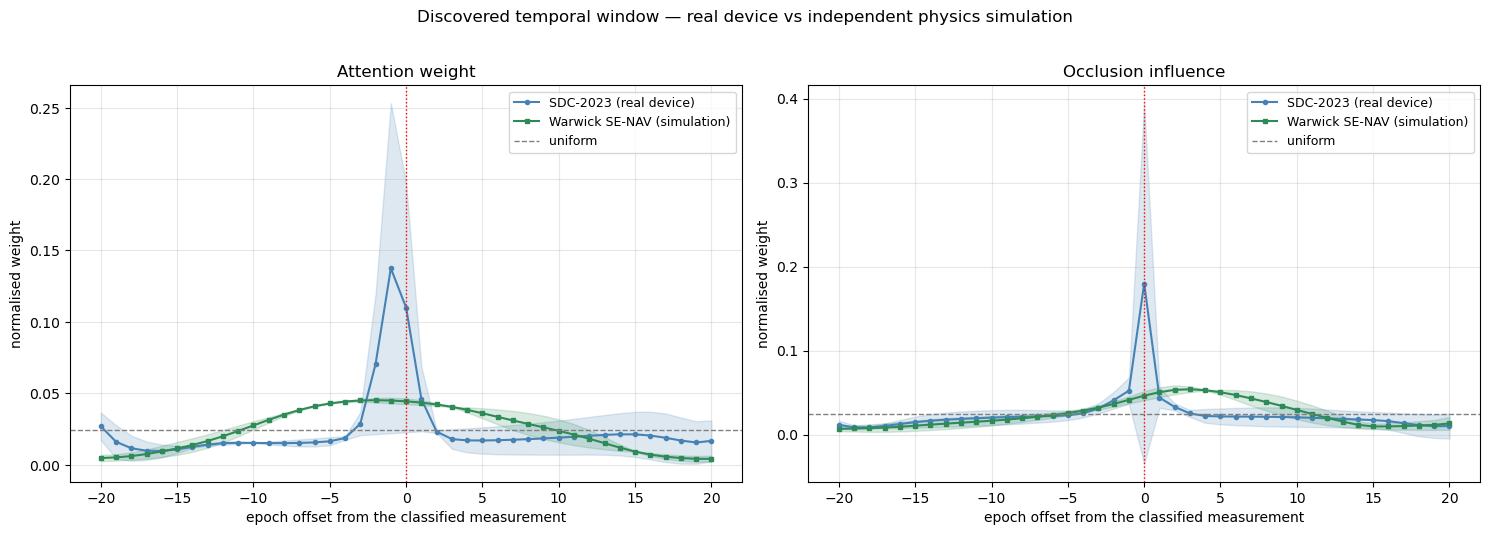

In [9]:
sdc_prof_npz = np.load(os.path.join(ART_DIR, 'sdc_attention_profiles.npz'))
sdc_attn = {k.split('|', 1)[1]: sdc_prof_npz[k] for k in sdc_prof_npz.files if k.startswith('attn|')}
sdc_occ  = {k.split('|', 1)[1]: sdc_prof_npz[k] for k in sdc_prof_npz.files if k.startswith('occ|')}

def norm_mean(profiles_dict):
    """Average across variants/heads after normalising each to unit mass."""
    stack = []
    for p in profiles_dict.values():
        p = np.atleast_2d(p)
        for h in range(p.shape[0]):
            stack.append(p[h] / p[h].sum())
    return np.mean(stack, axis=0), np.std(stack, axis=0)

sdc_a_mu, sdc_a_sd = norm_mean(sdc_attn)
war_a_mu, war_a_sd = norm_mean(war_profiles)
sdc_o_mu, sdc_o_sd = norm_mean(sdc_occ)
war_o_mu, war_o_sd = norm_mean(war_occ)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharex=True)
for ax, (s_mu, s_sd, w_mu, w_sd, title) in zip(axes, [
        (sdc_a_mu, sdc_a_sd, war_a_mu, war_a_sd, 'Attention weight'),
        (sdc_o_mu, sdc_o_sd, war_o_mu, war_o_sd, 'Occlusion influence')]):
    ax.plot(offsets, s_mu, 'o-', ms=3, color='steelblue', label='SDC-2023 (real device)')
    ax.fill_between(offsets, s_mu - s_sd, s_mu + s_sd, color='steelblue', alpha=0.18)
    ax.plot(offsets, w_mu, 's-', ms=3, color='seagreen', label='Warwick SE-NAV (simulation)')
    ax.fill_between(offsets, w_mu - w_sd, w_mu + w_sd, color='seagreen', alpha=0.18)
    ax.axhline(uniform, ls='--', color='gray', lw=1, label='uniform')
    ax.axvline(0, color='red', ls=':', lw=1)
    ax.set_xlabel('epoch offset from the classified measurement')
    ax.set_ylabel('normalised weight'); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Discovered temporal window — real device vs independent physics simulation', y=1.02)
plt.tight_layout(); plt.show()

In [10]:
def mass_within(p, k):
    c = len(p) // 2
    return float(p[c - k:c + k + 1].sum() / p.sum())

sdc_span_a = attention_span(sdc_a_mu, 0.90)
war_span_a = attention_span(war_a_mu, 0.90)
sdc_span_o = attention_span(sdc_o_mu, 0.90)
war_span_o = attention_span(war_o_mu, 0.90)

agree = pd.DataFrame([
    dict(measure='attention', dataset='SDC-2023', **{k: sdc_span_a[k] for k in
         ('k_symmetric', 'k_past', 'k_future', 'centre_weight')}),
    dict(measure='attention', dataset='Warwick', **{k: war_span_a[k] for k in
         ('k_symmetric', 'k_past', 'k_future', 'centre_weight')}),
    dict(measure='occlusion', dataset='SDC-2023', **{k: sdc_span_o[k] for k in
         ('k_symmetric', 'k_past', 'k_future', 'centre_weight')}),
    dict(measure='occlusion', dataset='Warwick', **{k: war_span_o[k] for k in
         ('k_symmetric', 'k_past', 'k_future', 'centre_weight')}),
])
print('Discovered window, both datasets:')
print(agree.round(4).to_string(index=False))

r_attn = float(np.corrcoef(sdc_a_mu, war_a_mu)[0, 1])
r_occ  = float(np.corrcoef(sdc_o_mu, war_o_mu)[0, 1])
print(f'\nProfile shape correlation   attention r = {r_attn:+.3f}   occlusion r = {r_occ:+.3f}')
print(f'\nCross-coverage (mass inside the *other* dataset\'s discovered window):')
print(f"  SDC profile inside Warwick's k={war_span_a['k_symmetric']}: "
      f"{100*mass_within(sdc_a_mu, war_span_a['k_symmetric']):.1f}%")
print(f"  Warwick profile inside SDC's k={sdc_span_a['k_symmetric']}: "
      f"{100*mass_within(war_a_mu, sdc_span_a['k_symmetric']):.1f}%")

Discovered window, both datasets:
  measure  dataset  k_symmetric  k_past  k_future  centre_weight
attention SDC-2023           18      18        18         0.1100
attention  Warwick           14      14        14         0.0443
occlusion SDC-2023           16      16        17         0.1798
occlusion  Warwick           15      16        15         0.0462

Profile shape correlation   attention r = +0.427   occlusion r = +0.443

Cross-coverage (mass inside the *other* dataset's discovered window):
  SDC profile inside Warwick's k=14: 80.6%
  Warwick profile inside SDC's k=18: 98.2%


### 5a. Warwick's own accuracy-vs-window sweep

The final independent check. Notebook 02 swept `k` on SDC and found where accuracy
plateaus; the same sweep is run here on Warwick alone. If the two datasets'
accuracy curves plateau at a similar `k`, that is the strongest form of the
agreement claim, because it is measured in test performance rather than in the
internals of an attention block.

  k= 1  test ROC-AUC 0.9999  F1 0.9929  RMpE 131,072
  k= 2  test ROC-AUC 1.0000  F1 0.9970  RMpE 218,368
  k= 3  test ROC-AUC 1.0000  F1 0.9930  RMpE 305,664
  k= 5  test ROC-AUC 0.9999  F1 0.9950  RMpE 480,256
  k= 8  test ROC-AUC 0.9999  F1 0.9894  RMpE 742,144
  k=12  test ROC-AUC 0.9996  F1 0.9934  RMpE 1,091,328
  k=14  test ROC-AUC 0.9995  F1 0.9896  RMpE 1,265,920
  k=15  test ROC-AUC 0.9999  F1 0.9857  RMpE 1,353,216
  k=20  test ROC-AUC 0.9993  F1 0.9882  RMpE 1,789,696


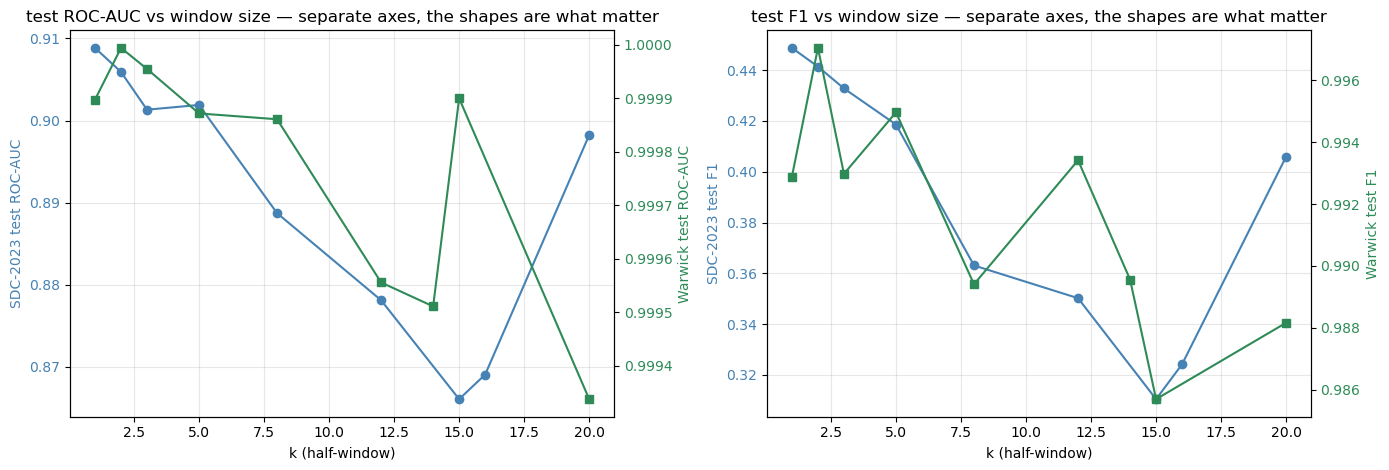

Warwick k-sweep:
 k  T  roc_auc  pr_auc     f1    RMpE
 1  3   0.9999  0.9994 0.9929  131072
 2  5   1.0000  1.0000 0.9970  218368
 3  7   1.0000  0.9997 0.9930  305664
 5 11   0.9999  0.9990 0.9950  480256
 8 17   0.9999  0.9989 0.9894  742144
12 25   0.9996  0.9944 0.9934 1091328
14 29   0.9995  0.9931 0.9896 1265920
15 31   0.9999  0.9989 0.9857 1353216
20 41   0.9993  0.9848 0.9882 1789696


In [11]:
K_SWEEP_W = sorted({1, 2, 3, 5, 8, 12, 20, K_WAR_ATTN, K_WAR_OCC})
war_sweep_rows = []
for k in K_SWEEP_W:
    set_seed(SEED)
    b = war_batchers(F_war_selfscaled, k, batch=BATCH, shuffle_train=True)
    m = AttnBRNN(len(SHARED_COLS), hidden=HYPER['hidden'], layers=HYPER['layers'],
                 rnn='lstm', attn='unpacked', dropout=HYPER['dropout']).to(DEVICE)
    m, _, bv = train_model(m, b['train'], b['val'], pos_weight=pw_war, epochs=EPOCHS,
                           lr=LR, patience=PATIENCE, verbose=False)
    thr = tune_threshold(collect_labels(b['val']), predict_proba(m, b['val']))
    r = evaluate(collect_labels(b['test']), predict_proba(m, b['test']), thr)
    r.update(k=k, T=2 * k + 1, RMpE=rmpe(m, k), val_auc=bv)
    war_sweep_rows.append(r)
    print(f'  k={k:>2}  test ROC-AUC {r["roc_auc"]:.4f}  F1 {r["f1"]:.4f}  RMpE {r["RMpE"]:,}')

war_sweep = pd.DataFrame(war_sweep_rows).sort_values('k').reset_index(drop=True)
sdc_sweep = pd.read_csv(os.path.join(ART_DIR, 'sdc_k_sweep.csv')).sort_values('k')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, metric, lbl in [(axes[0], 'roc_auc', 'test ROC-AUC'), (axes[1], 'f1', 'test F1')]:
    a = ax.twinx()
    ax.plot(sdc_sweep.k, sdc_sweep[metric], 'o-', color='steelblue', label='SDC-2023 (left axis)')
    a.plot(war_sweep.k, war_sweep[metric], 's-', color='seagreen', label='Warwick (right axis)')
    ax.set_xlabel('k (half-window)')
    ax.set_ylabel(f'SDC-2023 {lbl}', color='steelblue')
    a.set_ylabel(f'Warwick {lbl}', color='seagreen')
    ax.tick_params(axis='y', labelcolor='steelblue'); a.tick_params(axis='y', labelcolor='seagreen')
    ax.set_title(f'{lbl} vs window size — separate axes, the shapes are what matter')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Warwick k-sweep:')
print(war_sweep[['k', 'T', 'roc_auc', 'pr_auc', 'f1', 'RMpE']].round(4).to_string(index=False))

In [12]:
def plateau_k(df, metric='roc_auc', tol=0.01):
    """Smallest k reaching within `tol` (relative) of the best score in the sweep."""
    best = df[metric].max()
    ok = df[df[metric] >= best * (1 - tol)]
    return int(ok.k.min())

p_sdc = plateau_k(sdc_sweep); p_war = plateau_k(war_sweep)
print(f'Smallest k within 1% of the best test ROC-AUC:')
print(f'  SDC-2023 : k = {p_sdc}   ({2*p_sdc+1} epochs)')
print(f'  Warwick  : k = {p_war}   ({2*p_war+1} epochs)')

summary = pd.DataFrame([
    dict(evidence='attention 90% mass',   sdc=sdc_span_a['k_symmetric'], warwick=war_span_a['k_symmetric']),
    dict(evidence='occlusion 90% mass',   sdc=sdc_span_o['k_symmetric'], warwick=war_span_o['k_symmetric']),
    dict(evidence='accuracy plateau (1%)', sdc=p_sdc,                    warwick=p_war),
])
summary['agree_within'] = (summary.sdc - summary.warwick).abs()
print('\n=== Window-shape agreement across three independent measurements ===')
print(summary.to_string(index=False))

Smallest k within 1% of the best test ROC-AUC:
  SDC-2023 : k = 1   (3 epochs)
  Warwick  : k = 1   (3 epochs)

=== Window-shape agreement across three independent measurements ===
             evidence  sdc  warwick  agree_within
   attention 90% mass   18       14             4
   occlusion 90% mass   16       15             1
accuracy plateau (1%)    1        1             0


In [13]:
war_df.to_csv(os.path.join(ART_DIR, 'warwick_model_results.csv'), index=False)
war_sweep.to_csv(os.path.join(ART_DIR, 'warwick_k_sweep.csv'), index=False)
transfer.to_csv(os.path.join(ART_DIR, 'transfer_results.csv'), index=False)
summary.to_csv(os.path.join(ART_DIR, 'window_shape_agreement.csv'), index=False)
np.savez(os.path.join(ART_DIR, 'warwick_attention_profiles.npz'),
         offsets=offsets,
         **{f'attn|{k}': v for k, v in war_profiles.items()},
         **{f'occ|{k}': v for k, v in war_occ.items()})
print('Saved transfer + Warwick artefacts to', ART_DIR)

Saved transfer + Warwick artefacts to c:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/03_processed/attn_brnn


## 6. Takeaways

Fill these against the printed tables — the numbers above are the result, not this
list.

- **Sequence transfer (§2).** The SDC-trained attention BRNN applied cold to the
  Warwick simulation, measured against the ~0.94 ROC-AUC per-measurement RF
  baseline re-run on identical rows. As in `sdc_to_warwick_transfer.ipynb`, the
  *ranking* is what transfers: the operating threshold still needs recalibrating on
  the target, because the simulation's C/N0 sits ~12 dB above the real device's.
- **Independent window discovery (§4–5).** Warwick's own model, trained without
  ever seeing SDC data, produces its own attention and occlusion profiles. The
  three-row agreement table in §5a is the result: attention span, occlusion span
  and accuracy plateau, each measured separately on each dataset.
- **How to read agreement.** If the discovered windows match, the temporal memory
  is a property of the multipath process — a receiver moving past a reflector for a
  characteristic number of seconds — rather than of the Android `MultipathIndicator`
  flag or of SE-NAV's ray tracer. That complements the *feature-level* transfer
  already established in `sdc_to_warwick_transfer.ipynb`: features transfer, and so
  does the timescale.
- **How to read disagreement.** If they differ, say so. The most likely mundane
  explanations, which the dissertation should address rather than dismiss: Warwick
  is 20x smaller and noise-free, its labels are far more persistent (0.98 vs 0.49
  at lag 1), it is GPS-only, and its NLOS label is geometric while SDC's is a
  hardware flag of uncertain definition.
- **Caveats inherited from the existing transfer notebook.** Different label
  semantics (`MultipathIndicator` vs simulated `Visibility`), an idealised
  noise-free simulation, and GPS-only coverage. This is an out-of-distribution
  sanity check, not an in-distribution test.